In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import cv2
import xml.etree.ElementTree as ET
from IPython.display import Image, display



Set paths and check videos

In [ ]:
# Your PIE dataset path
PIE_PATH = "/content/drive/MyDrive/PIE"


# Find all video files
video_files = glob.glob(f"{PIE_PATH}/PIE_clips/**/*.mp4", recursive=True)

print(f"Found {len(video_files)} video files")

# Show first 2 videos
print("\nFirst 2 videos:")
for v in video_files[:2]:
    print(f"   {os.path.basename(v)}")

Found 65 video files

First 2 videos:
   video_0001.mp4
   video_0002.mp4


Frame extracion (testing for one video)

In [ ]:
# Pick first video
if video_files:
    test_video = video_files[0]
    print(f"Processing: {test_video}")

    # Create output folder for frames
    # Extract video name without extension
    video_name = os.path.basename(test_video).replace('.mp4', '')

    # Get set name (set01, set02, etc.)
    set_name = os.path.basename(os.path.dirname(test_video))

    # Output path: PIE/images/set01/video_0001/
    output_folder = f"{PIE_PATH}/images/{set_name}/{video_name}"
    os.makedirs(output_folder, exist_ok=True)

    print(f"Output folder: {output_folder}")

    # Extract frames
    cap = cv2.VideoCapture(test_video)
    frame_count = 0
    extracted = 0

    # Extract first 30 frames only (for testing)
    while frame_count < 30:
        ret, frame = cap.read()
        if not ret:
            break

        # Save frame as image
        frame_filename = f"{output_folder}/frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_filename, frame)

        frame_count += 1
        extracted += 1

    cap.release()

    print(f"\nExtracted {extracted} frames from {video_name}")
    print(f"   Saved to: {output_folder}")
else:
    print("❌ No videos found. Check your PIE_clips folder.")

Processing: /content/drive/MyDrive/PIE/PIE_clips/set01/video_0001.mp4
Output folder: /content/drive/MyDrive/PIE/images/set01/video_0001

Extracted 30 frames from video_0001
   Saved to: /content/drive/MyDrive/PIE/images/set01/video_0001


Verify extracted frames

Found 30 frames

First 2 frames:
   frame_00000.jpg
   frame_00001.jpg

Displaying first frame:


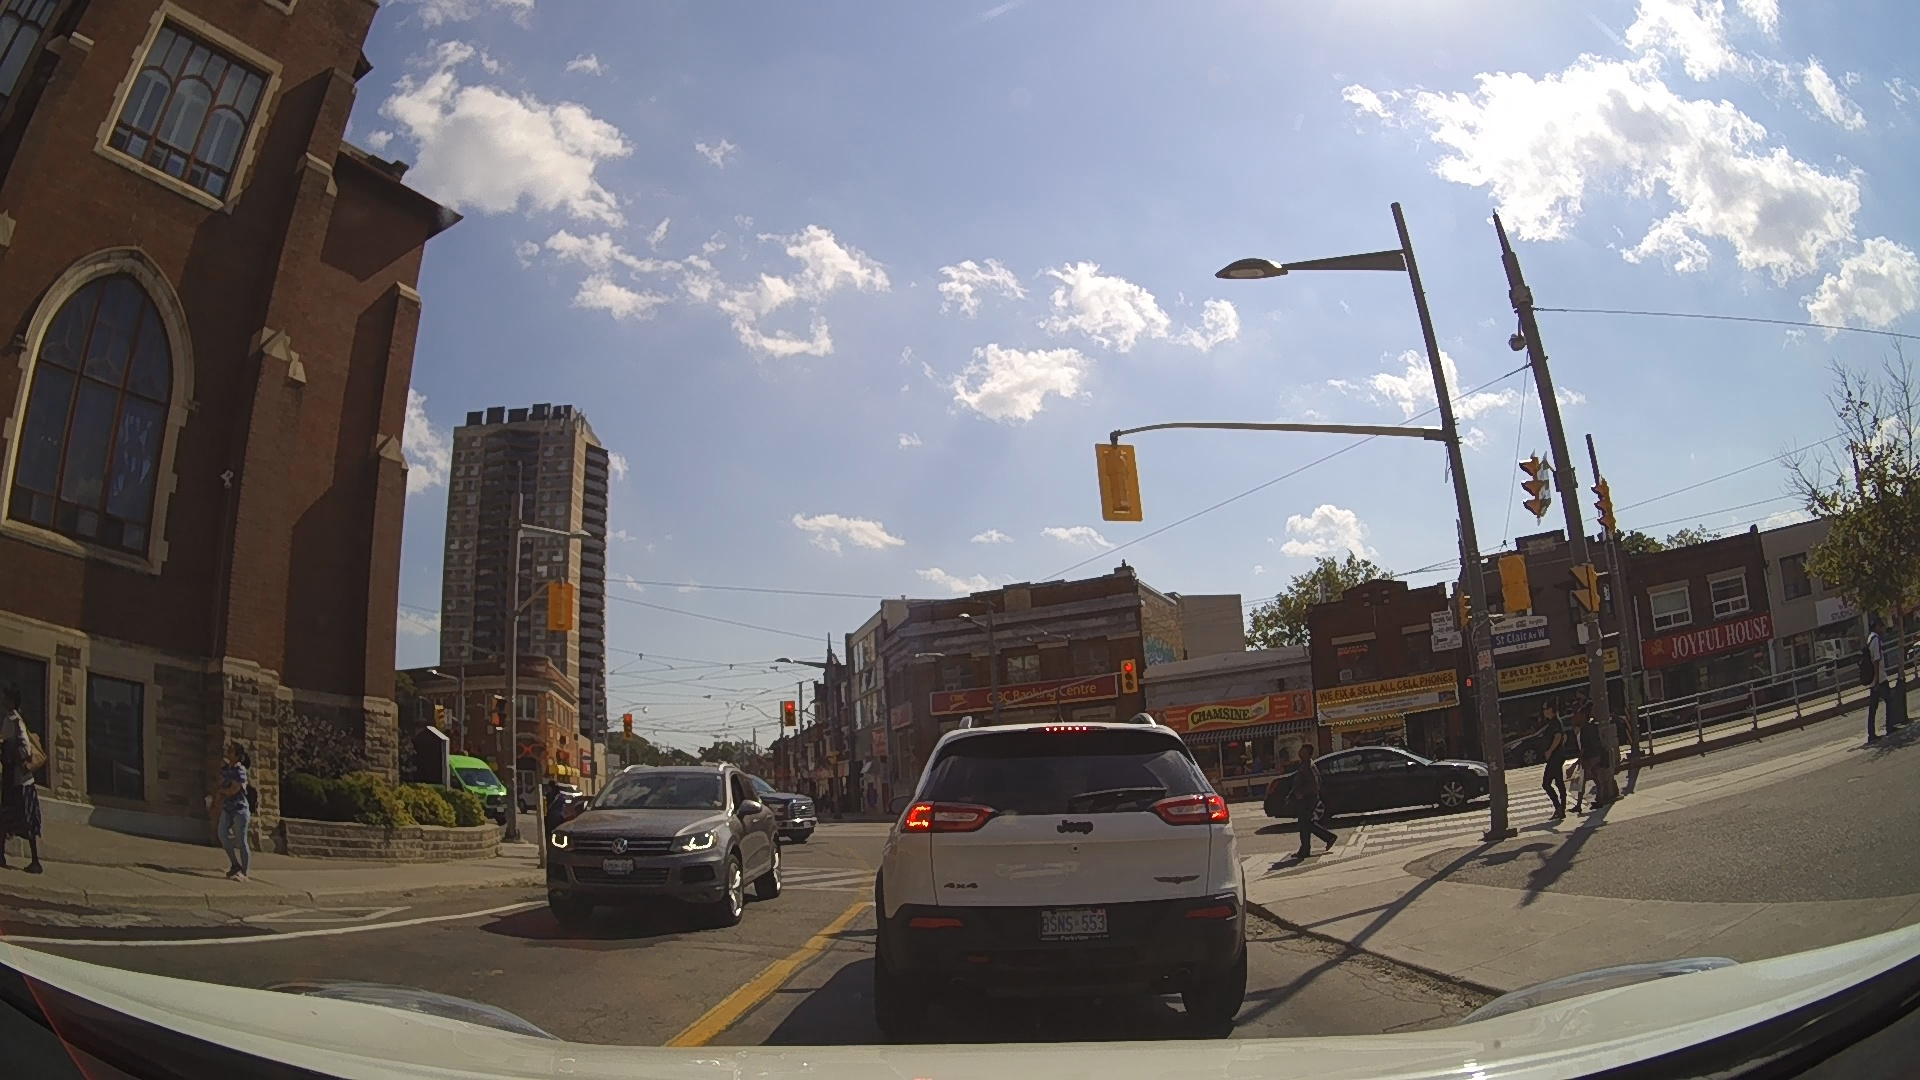

In [ ]:
# Check extracted frames
frames_folder = f"{PIE_PATH}/images/set01/video_0001"
if os.path.exists(frames_folder):
    frames = sorted(os.listdir(frames_folder))[:2]

    print(f"Found {len(os.listdir(frames_folder))} frames")
    print(f"\nFirst 2 frames:")
    for f in frames:
        print(f"   {f}")

    # Display first frame
    if frames:
        print("\nDisplaying first frame:")
        display(Image(f"{frames_folder}/{frames[0]}", width=400))
else:
    print("Frames folder not found.")

EXTRACT ALL ANNOTATED FRAMES

In [ ]:
import os
import glob
import xml.etree.ElementTree as ET
import cv2
from collections import defaultdict

print("="*60)
print("PROCESSING ALL 6 SETS - SKIPS ALREADY PROCESSED VIDEOS")
print("="*60)

PIE_PATH = "/content/drive/MyDrive/PIE"

# Find ALL annotation files recursively
ann_files = glob.glob(f"{PIE_PATH}/annotations/**/*_annt.xml", recursive=True)
print(f"Found {len(ann_files)} total annotation files")

# Group by set to see distribution
set_counts = defaultdict(int)
for f in ann_files:
    set_name = f.split('/')[-2]
    set_counts[set_name] += 1

print("\nAnnotation files per set:")
for set_name in sorted(set_counts.keys()):
    print(f"   {set_name}: {set_counts[set_name]} files")

# Statistics
total_frames_extracted = 0
processed_videos = 0
skipped_videos = 0

for idx, ann_file in enumerate(ann_files):
    # Extract set name and video number
    parts = ann_file.split('/')
    set_name = parts[-2]  # "set01", "set02", etc.

    # Extract video number from filename
    base_name = os.path.basename(ann_file)
    video_num = base_name.replace(f'{set_name}_video_', '').replace('_annt.xml', '')

    # CHECK IF ALREADY PROCESSED - THIS IS THE KEY ADDITION!
    output_folder = f"{PIE_PATH}/images_annotated/{set_name}/{video_num}"

    if os.path.exists(output_folder):
        # Count existing frames to verify
        existing_frames = len(glob.glob(f"{output_folder}/*.jpg"))
        if existing_frames > 0:
            print(f"\n[{idx+1}/{len(ann_files)}] SKIPPING: {set_name}/{video_num}")
            print(f"   Already processed: {existing_frames} frames exist")
            skipped_videos += 1
            total_frames_extracted += existing_frames
            continue

    print(f"\n[{idx+1}/{len(ann_files)}] Processing: {os.path.basename(ann_file)}")

    # Find video file
    video_file = f"{PIE_PATH}/PIE_clips/{set_name}/{video_num}.mp4"

    if not os.path.exists(video_file):
        print(f"   Video not found: {video_file}")
        continue

    print(f"   Video: {set_name}/{video_num}.mp4")

    # Parse XML to get frames with pedestrians
    tree = ET.parse(ann_file)
    root = tree.getroot()

    frames_with_pedestrians = set()
    for box in root.findall('.//box'):
        frame_attr = box.get('frame')
        if frame_attr is not None:
            frames_with_pedestrians.add(int(frame_attr))

    print(f"   Frames with pedestrians: {len(frames_with_pedestrians)}")

    if len(frames_with_pedestrians) == 0:
        print("   No pedestrian frames found, skipping")
        continue

    # Extract frames
    cap = cv2.VideoCapture(video_file)
    os.makedirs(output_folder, exist_ok=True)

    frame_count = 0
    extracted = 0

    print(f"   Extracting frames...")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count in frames_with_pedestrians:
            cv2.imwrite(f"{output_folder}/frame_{frame_count:05d}.jpg", frame)
            extracted += 1

            # Progress update every 500 frames
            if extracted % 500 == 0:
                print(f"      Extracted {extracted} frames...")

        frame_count += 1

    cap.release()
    total_frames_extracted += extracted
    processed_videos += 1
    print(f"   Extracted {extracted} frames (Video {processed_videos} completed)")

print(f"\n" + "="*60)
print(f"   PROCESSING COMPLETE!")
print(f"   New videos processed: {processed_videos}")
print(f"   Videos skipped (already done): {skipped_videos}")
print(f"   Total frames extracted (including skipped): {total_frames_extracted}")
print("="*60)

PROCESSING ALL 6 SETS - SKIPS ALREADY PROCESSED VIDEOS
Found 53 total annotation files

Annotation files per set:
   set01: 4 files
   set02: 3 files
   set03: 19 files
   set04: 16 files
   set05: 2 files
   set06: 9 files

[1/53] SKIPPING: set04/video_0001
   Already processed: 4871 frames exist

[2/53] SKIPPING: set04/video_0003
   Already processed: 7126 frames exist

[3/53] SKIPPING: set04/video_0002
   Already processed: 8246 frames exist

[4/53] SKIPPING: set04/video_0004
   Already processed: 6595 frames exist

[5/53] SKIPPING: set04/video_0005
   Already processed: 4296 frames exist

[6/53] SKIPPING: set04/video_0006
   Already processed: 6017 frames exist

[7/53] SKIPPING: set04/video_0007
   Already processed: 11292 frames exist

[8/53] SKIPPING: set04/video_0008
   Already processed: 4903 frames exist

[9/53] SKIPPING: set04/video_0010
   Already processed: 5003 frames exist

[10/53] SKIPPING: set04/video_0011
   Already processed: 9551 frames exist

[11/53] SKIPPING: set04

In [1]:
import numpy as np
import os
import glob

print("="*60)
print("VERIFYING LANDMARK FILES")
print("="*60)

PIE_PATH = "/content/drive/MyDrive/PIE"

# Count total landmark files
landmark_files = glob.glob(f"{PIE_PATH}/landmarks/**/*.npy", recursive=True)
print(f"✅ Total landmark files: {len(landmark_files)}")

# Check one file
if landmark_files:
    sample_file = landmark_files[0]
    print(f"\n📄 Sample file: {sample_file}")

    # Load landmarks
    landmarks = np.load(sample_file)
    print(f"   Shape: {landmarks.shape}")  # Should be (99,)
    print(f"   First 3 landmarks (x,y,z for nose): {landmarks[:9]}")

    # Verify 33 landmarks
    num_landmarks = len(landmarks) // 3
    print(f"   Number of landmarks: {num_landmarks} (33 expected)")

    if num_landmarks == 33:
        print("✅ Correct! 33 landmarks detected")
    else:
        print(f"⚠️ Found {num_landmarks} landmarks")

VERIFYING LANDMARK FILES
✅ Total landmark files: 33279

📄 Sample file: /content/drive/MyDrive/PIE/landmarks/set01/video_0004/frame_00004.npy
   Shape: (99,)
   First 3 landmarks (x,y,z for nose): [0.83231443 0.59367162 0.03761886 0.83320624 0.59412694 0.03164866
 0.83276391 0.58607066 0.03160397]
   Number of landmarks: 33 (33 expected)
✅ Correct! 33 landmarks detected
